In [2]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

from hubble_fit import *
from hubble_utils import load_agn_data

CPU Num Cores: 30


In [3]:
#df_agn = load_quasar_data("results/data/aug15b_stone_nobwb_diffpriors_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False)

df_agn = load_agn_data("results/data/sep14_chisq_lmc2_warmergate_etaagnostic_N20w6000s500t8co5ch4.h5", populate_sdss=False, only_load=True)

len(df_agn)

Reading quasars from HDF5: 100%|██████████| 720/720 [00:06<00:00, 114.26it/s]

Number of quasars loaded: 720


720

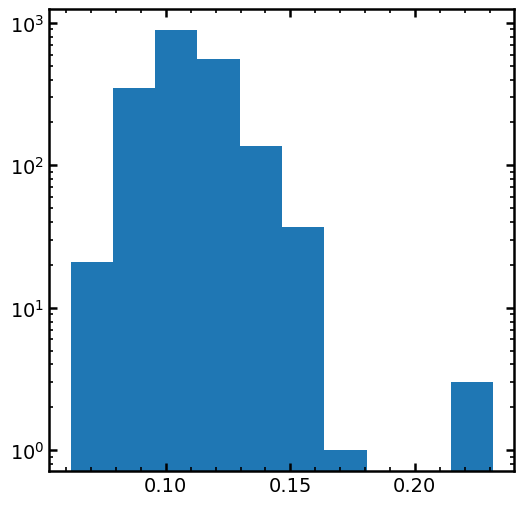

In [36]:
plt.hist(df_agn['log_sigma_UV_err'], log=True, color='C0')
plt.show()

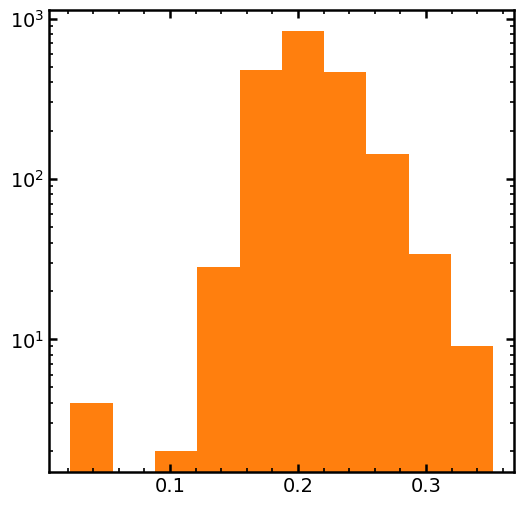

In [37]:
plt.hist(df_agn['log_tau_UV_RF_err'], log=True, color='C1')
plt.show()

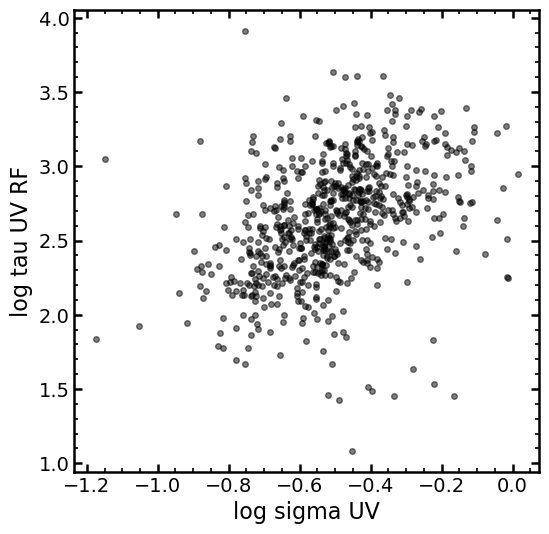

In [4]:
plt.errorbar(df_agn['log_sigma_UV'], df_agn['log_tau_UV_RF'], 
linestyle='none', marker='o', alpha=0.5, color='k')
plt.xlabel('log sigma UV')
plt.ylabel('log tau UV RF')
plt.show()

In [5]:
bands = ['u', 'g', 'r', 'i', 'z']

from collections import OrderedDict

def sdss_broad_lines_by_band(z):
    """
    Return a dict mapping each SDSS band to the name of a broad line
    whose observed wavelength falls inside that band's (approximate) range
    at redshift z. If none, returns "none" for that band.

    Notes:
    - Filter edges are approximated as simple top-hats (Å).
    - Lines are checked in priority order; if multiple lines land in a band,
      the first match is returned.
    """

    # --- approximate SDSS bandpass ranges (Å); simple top-hat model ---
    bands = {
        "u": (3000.0, 4000.0),
        "g": (4000.0, 5500.0),
        "r": (5500.0, 7000.0),
        "i": (7000.0, 8500.0),
        "z": (8500.0, 10000.0),
    }

    # --- common broad lines (rest Å), in priority order ---
    lines = OrderedDict([
        ("Lyα 1216", 1215.67),
        #("N V 1240", 1240.81),
        #("Si IV+O IV] 1400", 1397.0),
        ("C IV 1549", 1549.0),
        #("He II 1640", 1640.0),
        ("C III] 1909", 1908.73),
        ("Mg II 2798", 2798.0),
        #("Hγ 4340", 4340.47),
        ("Hβ 4861", 4861.33),
        ("Hα 6563", 6562.80),
    ])

    out = {}
    for band, (lo, hi) in bands.items():
        hit = "none"
        for name, lam0 in lines.items():
            lam_obs = lam0 * (1.0 + z)
            if lo + 0 <= lam_obs <= hi - 0:
                hit = name
                break
        out[band] = hit
    return out

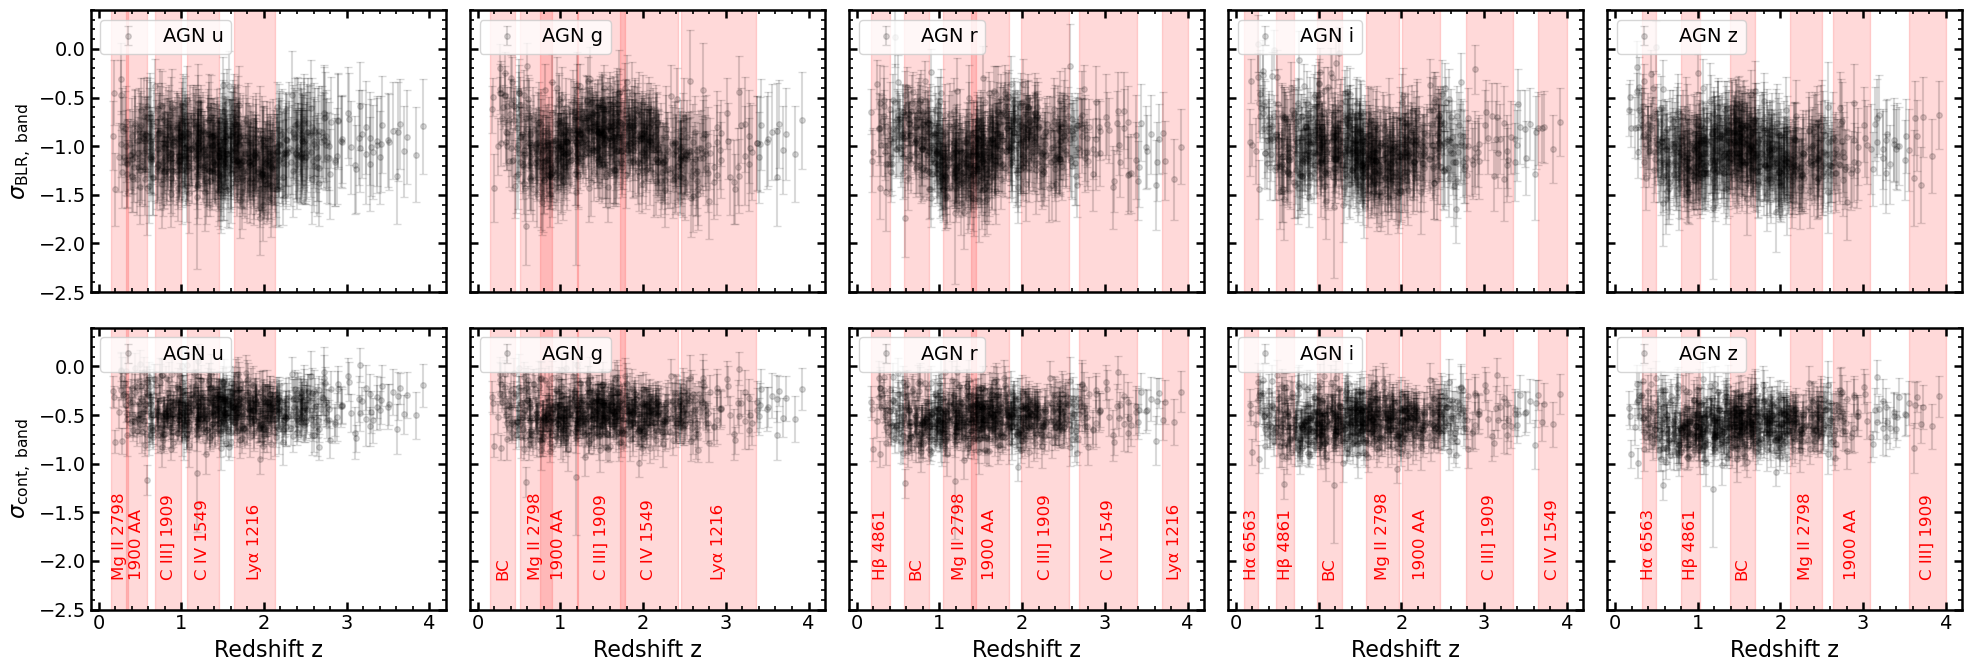

In [6]:
import matplotlib.pyplot as plt
import numpy as np

bands = ['u', 'g', 'r', 'i', 'z']

fig, axes = plt.subplots(2, len(bands), figsize=(4 * len(bands), 7), sharey=True, sharex=True)

for i, b in enumerate(bands):
    z = df_agn['z']
    sigma_blr = df_agn[f'log_sigma0'] + df_agn[f'log_amp_delta_blr_{b}']
    sigma_blr_err = np.sqrt(df_agn[f'log_sigma0_err']**2 + df_agn[f'log_amp_delta_blr_{b}_err']**2)
    axes[0,i].errorbar(z, sigma_blr, yerr=sigma_blr_err, linestyle='none', marker='o', alpha=0.15, color='k', label=f'AGN {b}')
    axes[0,i].legend(loc='upper left')
    if i == 0:
        axes[0,i].set_ylabel(r'$\sigma_\mathrm{BLR,\ band}$')

for i, b in enumerate(bands):
    z = df_agn['z']
    sigma_blr = df_agn[f'log_sigma_band_{b}']
    sigma_blr_err = df_agn[f'log_sigma_band_{b}_err']
    axes[1,i].errorbar(z, sigma_blr, yerr=sigma_blr_err, linestyle='none', marker='o', alpha=0.15, color='k', label=f'AGN {b}')
    axes[1,i].set_xlabel('Redshift z')
    axes[1,i].legend(loc='upper left')
    axes[1,i].set_ylim(-2.5, 0.4)
    if i == 0:
        axes[1,i].set_ylabel(r'$\sigma_\mathrm{cont,\ band}$')

# Draw vertical fill for major emission lines in each band as a function of redshift
line_wavelengths = {
    "Lyα 1216": 1215.67,
    "C IV 1549": 1549.0,
    "C III] 1909": 1908.73,
    #"Fe II UV bump": (2800 + 2200)/2,
    "1900 AA": 2400.0,
    "Mg II 2798": 2798.0,
    "Hβ 4861": 4861.33,
    "Hα 6563": 6562.80,
    # balmer continuum
    "BC": 3646.0,  # Approximate wavelength for the Balmer continuum
}
band_edges = {
    "u": (3000.0, 4000.0),
    "g": (4000.0, 5500.0),
    "r": (5500.0, 7000.0),
    "i": (7000.0, 8500.0),
    "z": (8500.0, 10000.0),
}

z_grid = np.linspace(0, 4, 600)
for i, b in enumerate(bands):
    lo, hi = band_edges[b]
    for line_name, lam0 in line_wavelengths.items():
        lam_obs = lam0 * (1.0 + z_grid)
        in_band = (lam_obs >= lo + 200) & (lam_obs <= hi - 200)
        if np.any(in_band):
            diff = np.diff(in_band.astype(int))
            entry_indices = np.where(diff == 1)[0] + 1
            exit_indices = np.where(diff == -1)[0] + 1
            if in_band[0]:
                entry_indices = np.insert(entry_indices, 0, 0)
            if in_band[-1]:
                exit_indices = np.append(exit_indices, len(z_grid)-1)
            # Fill between entry and exit redshifts
            for entry, exit in zip(entry_indices, exit_indices):
                z_start = z_grid[entry]
                z_end = z_grid[exit]
                if (df_agn['z'].min() < z_end and z_start < df_agn['z'].max()):
                    axes[0, i].axvspan(z_start, z_end, color='r', alpha=0.15, zorder=-1)
                    axes[1, i].axvspan(z_start, z_end, color='r', alpha=0.15, zorder=-1)
                    # Optionally, label the line at the top
                    axes[1, i].text((z_start+z_end)/2, axes[0, i].get_ylim()[0]+0.3, line_name,
                                    color='r', rotation=90, va='bottom', ha='center', fontsize=12)

fig.tight_layout()
plt.show()
fig.savefig('plots/appendix/blr.pdf', dpi=600)

In [41]:
snr = (df_agn[f'log_sigma0'] + df_agn[f'log_amp_delta_blr_{b}'])/df_agn[f'log_sigma_band_{b}']
plt.scatter(snr, df_agn[f'log_lag_blr_{b}_err'])

Text(0, 0.5, 'log BLR lag')

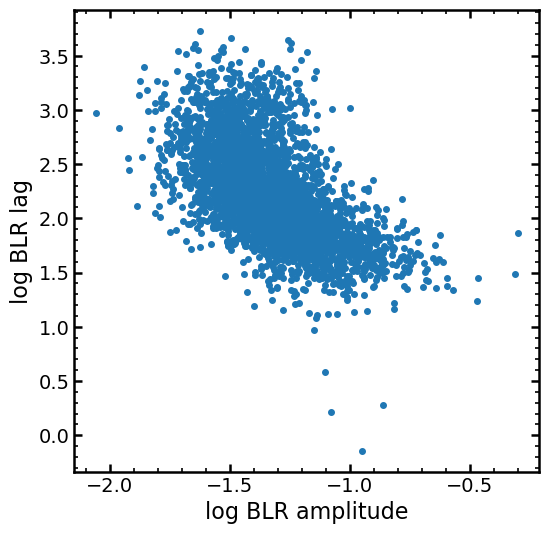

In [58]:
plt.scatter((df_agn[f'log_sigma0'] + df_agn[f'log_amp_delta_blr_{b}']), df_agn[f'log_lag_blr_{b}'])
plt.xlabel('log BLR amplitude')
plt.ylabel('log BLR lag')

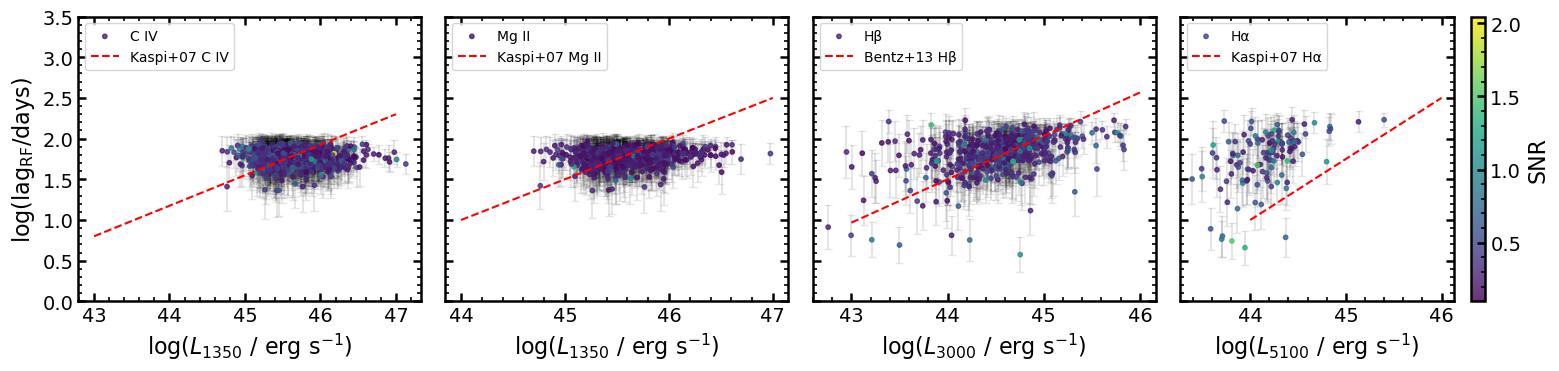

In [46]:
import matplotlib.pyplot as plt
import numpy as np

broad_lines = ["C IV 1549", "Mg II 2798", "Hβ 4861", "Hα 6563"]
conti_lam =   [1350,       1350,        3000,          5100,      5100]

fig, axes = plt.subplots(1, len(broad_lines), figsize=(4 * len(broad_lines), 4), sharey=True)
lines_by_obj = [sdss_broad_lines_by_band(z) for z in df_agn['z']]

# Gather all SNR values for color normalization
all_snr = []
all_logl = []
all_lag = []
all_lag_err = []
all_z = []
all_panel = []

for i, line in enumerate(broad_lines):
    mask = np.array([line in d.values() for d in lines_by_obj])
    z = df_agn['z'][mask]
    logl = df_agn[f'LOGL{conti_lam[i]}'][mask]
    bands_for_line = [next(b for b, l in d.items() if l == line) for d in np.array(lines_by_obj)[mask]]
    lag = np.array([df_agn[f'log_lag_blr_{b}'][j] for j, b in zip(np.where(mask)[0], bands_for_line)])
    lag_err = np.array([df_agn[f'log_lag_blr_{b}_err'][j] for j, b in zip(np.where(mask)[0], bands_for_line)])
    log_sigma_band = np.array([df_agn[f'log_sigma_band_{b}'][j] for j, b in zip(np.where(mask)[0], bands_for_line)])
    log_sigma_blr = np.array([df_agn[f'log_sigma0'][j] + df_agn[f'log_amp_delta_blr_{b}'][j] for j, b in zip(np.where(mask)[0], bands_for_line)])
    snr = 10**log_sigma_blr / 10**log_sigma_band
    mask2 = (logl > 0)
    # Store for global color scale
    all_snr.append(snr[mask2])
    all_logl.append(logl[mask2])
    all_lag.append(lag[mask2] - np.log10(1 + z[mask2]))
    all_lag_err.append(lag_err[mask2])
    all_z.append(z[mask2])
    all_panel.append(np.full(np.sum(mask2), i))

# Flatten arrays
all_snr = np.concatenate(all_snr)
all_logl = np.concatenate(all_logl)
all_lag = np.concatenate(all_lag)
all_lag_err = np.concatenate(all_lag_err)
all_z = np.concatenate(all_z)
all_panel = np.concatenate(all_panel)

# Get global vmin/vmax for color scale
vmin, vmax = np.nanmin(all_snr), np.nanmax(all_snr)

scs = []
for i, line in enumerate(broad_lines):
    idx = (all_panel == i)
    mask = all_snr[idx] > 0.1
    sc = axes[i].scatter(all_logl[idx][mask], all_lag[idx][mask], s=10, c=all_snr[idx][mask], cmap='viridis', alpha=0.8, vmin=vmin, vmax=vmax, label=f'{line[:-5]}')
    #axes[i].scatter(all_logl[idx], all_lag[idx], s=10, alpha=0.1, c='k', label=f'{line[:-5]}', zorder=-1)
    scs.append(sc)
    axes[i].errorbar(all_logl[idx][mask], all_lag[idx][mask], yerr=all_lag_err[idx][mask], linestyle='none', marker='none', alpha=0.1, color='k', zorder=-1)
    if broad_lines[i] == "Hα 6563":
        axes[i].plot([44, 46], [1.5 + 0.5 * (x - 44) for x in [43, 46]], 'r--', label='Kaspi+07 Hα')
    elif broad_lines[i] == "Hβ 4861":
        axes[i].plot([43, 46], [1.5 + 0.533 * (x - 44) for x in [43, 46]], 'r--', label='Bentz+13 Hβ')
    elif broad_lines[i] == "Mg II 2798":
        axes[i].plot([44, 47], [1.5 + 0.5 * (x - 44) for x in [43, 46]], 'r--', label='Kaspi+07 Mg II')
    elif broad_lines[i] == "C IV 1549":
        axes[i].plot([43, 47], [1.3 + 0.5 * (x - 44) for x in [43, 46]], 'r--', label='Kaspi+07 C IV')
    axes[i].legend(loc='upper left', fontsize=10)
    axes[i].set_xlabel(rf'$\log( L_{{{conti_lam[i]}}} \ /\ \mathrm{{erg}} \ \mathrm{{s}}^{{-1}} )$')
    if i == 0:
        axes[i].set_ylabel(r'$\log(\mathrm{lag}_{\mathrm{RF}} / \mathrm{days})$')
    # Only add colorbar to the rightmost panel
    if i == len(broad_lines) - 1:
        fig.colorbar(scs[i], label='SNR')
    axes[i].set_ylim(0, 3.5)
    #axes[i].set_xlim(43.5, 47.5)

plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =======================
# CONFIG & CONSTANTS
# =======================
bands = ['u', 'g', 'r', 'i', 'z']
LOGL_ORDER = ['LOGL5100','LOGL3000','LOGL2500','LOGL1700','LOGL1350']  # available in your table
REST_WAVE = {'LOGL5100':5100.0, 'LOGL3000':3000.0, 'LOGL2500':2500.0, 'LOGL1700':1700.0, 'LOGL1350':1350.0}
L_REF_ANG = 5100.0  # convert to this rest wavelength when SED-normalizing

# Emission lines and bandpasses for shaded z-ranges (for z-panels)
line_wavelengths = {
    "Lyα 1216": 1215.67,
    "C IV 1549": 1549.0,
    "C III] 1909": 1908.73,
    "Fe bump≈2400": 2400.0,
    "Mg II 2798": 2798.0,
    "Hβ 4861": 4861.33,
    "Hα 6563": 6562.80,
    "Balmer cont 3646": 3646.0,
}
band_edges = {
    "u": (3000.0, 4000.0),
    "g": (4000.0, 5500.0),
    "r": (5500.0, 7000.0),
    "i": (7000.0, 8500.0),
    "z": (8500.0, 10000.0),
}

# =======================
# HELPERS
# =======================
def choose_first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def best_logL_per_row(df, order=LOGL_ORDER):
    """Row-wise first positive LOGL in priority order."""
    L = np.full(len(df), np.nan, dtype=float)
    for col in order:
        if col in df.columns:
            v = pd.to_numeric(df[col], errors='coerce').to_numpy()
            take = np.isnan(L) & np.isfinite(v) & (v > 0)
            L[take] = v[take]
    return L

def best_logL_wavelength_per_row(df, order=LOGL_ORDER):
    """Companion array with the rest wavelength (Å) of the chosen LOGL per row."""
    lam = np.full(len(df), np.nan, dtype=float)
    for col in order:
        if col in df.columns:
            v = pd.to_numeric(df[col], errors='coerce').to_numpy()
            take = np.isnan(lam) & np.isfinite(v) & (v > 0)
            lam[take] = REST_WAVE[col]
    return lam

def mask_best_logL_positive(df, order=LOGL_ORDER):
    """Keep rows with any positive LOGL and cache the chosen one."""
    L = best_logL_per_row(df, order)
    m = np.isfinite(L) & (L > 0)
    out = df.loc[m].copy()
    out['_BEST_LOGL_'] = L[m]
    out['_BEST_LOGL_LAM_'] = best_logL_wavelength_per_row(df.loc[m], order)
    return out

def sed_to_Lref5100(df, alpha_col='alpha_agn', Lref=L_REF_ANG):
    """
    Convert the chosen LOGL (at its own rest wavelength) to an equivalent log L at Lref (5100Å)
    using L_lambda ∝ lambda^{alpha}. If alpha_agn missing, assume alpha=0 (no correction).
    """
    if '_BEST_LOGL_' not in df or '_BEST_LOGL_LAM_' not in df:
        df = mask_best_logL_positive(df)
    Lx = df['_BEST_LOGL_'].to_numpy(float)
    lamx = df['_BEST_LOGL_LAM_'].to_numpy(float)
    alpha = df[alpha_col].to_numpy(float) if alpha_col in df.columns else np.zeros_like(Lx)
    with np.errstate(invalid='ignore'):
        # log10 L_ref = log10 L_x + alpha * log10(Lref/lamx)
        Lref_log = Lx + alpha * np.log10(Lref / lamx)
    df = df.copy()
    df['_BEST_LOGL_5100_'] = Lref_log
    return df

def add_emission_line_spans(ax, z_min, z_max, band_key):
    lo, hi = band_edges[band_key]
    z_grid = np.linspace(max(0, np.nanmin([z_min, 0.])),
                         max(z_max, 0.01), 800)
    for _, lam0 in line_wavelengths.items():
        lam_obs = lam0 * (1.0 + z_grid)
        in_band = (lam_obs >= lo + 200) & (lam_obs <= hi - 200)
        if not np.any(in_band): continue
        diff = np.diff(in_band.astype(int))
        entry = np.where(diff == 1)[0] + 1
        exit_ = np.where(diff == -1)[0] + 1
        if in_band[0]: entry = np.insert(entry, 0, 0)
        if in_band[-1]: exit_ = np.append(exit_, len(z_grid) - 1)
        for a, b in zip(entry, exit_):
            ax.axvspan(z_grid[a], z_grid[b], alpha=0.10, zorder=-1)

def annotate_corr(ax, x, y, where=None, label_prefix="r"):
    if where is None:
        where = np.isfinite(x) & np.isfinite(y)
    xw, yw = np.asarray(x)[where], np.asarray(y)[where]
    if len(xw) < 5:
        ax.text(0.02, 0.98, "n<5", transform=ax.transAxes, va="top")
        return
    r = np.corrcoef(xw, yw)[0, 1]
    ax.text(0.02, 0.98, f"{label_prefix}≈{r:.2f}, n={len(xw)}",
            transform=ax.transAxes, va="top")

def deming(x, y, sx=None, sy=None, lam=1.0):
    """
    Simple Deming regression (errors-in-variables).
    If sx, sy not given, falls back to OLS.
    lam = variance ratio = (sx^2)/(sy^2) if you know it; default 1.
    Returns slope, intercept.
    """
    x = np.asarray(x); y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return np.nan, np.nan
    x, y = x[mask], y[mask]
    xbar, ybar = x.mean(), y.mean()
    Sxx = np.var(x, ddof=1); Syy = np.var(y, ddof=1); Sxy = np.cov(x,y, ddof=1)[0,1]
    if sx is not None and sy is not None:
        lam = np.nanmedian((sx[mask]**2) / (sy[mask]**2))
    delta = (Syy - lam*Sxx)
    beta = (delta + np.sqrt(delta**2 + 4*lam*Sxy**2)) / (2*Sxy)
    alpha = ybar - beta * xbar
    if not np.isfinite(beta):  # Fallback to OLS if degenerate
        beta, alpha = np.polyfit(x, y, 1)
    return beta, alpha

def apply_basic_filters(df, sn_col='sn_median_all', min_sn=None, lag_col=None, max_lag_err=None, min_n=50):
    """Optional quality cuts; returns filtered df and a short tag to append to plot titles."""
    tag = []
    out = df.copy()
    if min_sn is not None and sn_col in out.columns:
        out = out.loc[pd.to_numeric(out[sn_col], errors='coerce') >= float(min_sn)]
        tag.append(f"S/N≥{min_sn}")
    if max_lag_err is not None and lag_col is not None and f"{lag_col}_err" in out.columns:
        err = pd.to_numeric(out[f"{lag_col}_err"], errors='coerce')
        out = out.loc[err <= float(max_lag_err)]
        tag.append(f"σ_lag≤{max_lag_err}")
    if len(out) < min_n:
        # keep original if filtering destroys stats
        return df, "(no cut)"
    return out, ("; ".join(tag) if tag else "all")

# =======================
# LUMINOSITY HANDLING
# =======================
def ensure_best_L(df, to_5100=True):
    """Attach _BEST_LOGL_ (raw), and optionally _BEST_LOGL_5100_ (SED-corrected)."""
    if '_BEST_LOGL_' not in df.columns or '_BEST_LOGL_LAM_' not in df.columns:
        df = mask_best_logL_positive(df)
    if to_5100:
        if '_BEST_LOGL_5100_' not in df.columns:
            df = sed_to_Lref5100(df)
    return df

# =======================
# 1) σ_BLR vs z panels (unchanged physics, cleaner styling)
# =======================
def plot_sigma_vs_z_panels(df):
    z = df['z'].to_numpy(float) if 'z' in df.columns else np.full(len(df), np.nan)
    zmin, zmax = np.nanmin(z), np.nanmax(z)
    fig, axes = plt.subplots(2, len(bands), figsize=(4 * len(bands), 7), sharex=True)

    # Top: BLR sigma proxy = log_sigma0 + log_amp_delta_blr_{b}
    for i, b in enumerate(bands):
        ax = axes[0, i]
        need = ['log_sigma0', f'log_amp_delta_blr_{b}', 'log_sigma0_err', f'log_amp_delta_blr_{b}_err']
        if all(c in df.columns for c in need):
            y = df['log_sigma0'].to_numpy(float) + df[f'log_amp_delta_blr_{b}'].to_numpy(float)
            yerr = np.hypot(df['log_sigma0_err'].to_numpy(float),
                            df[f'log_amp_delta_blr_{b}_err'].to_numpy(float))
            ax.errorbar(z, y, yerr=yerr, linestyle='none', marker='o', alpha=0.15, label=f'AGN {b}')
        ax.set_title(f"{b}-band")
        if i == 0:
            ax.set_ylabel(r'$\log\,\sigma_{\rm BLR,\ band}$')
        add_emission_line_spans(ax, zmin, zmax, b); ax.legend(loc='upper left')

    # Bottom: continuum sigma per band
    for i, b in enumerate(bands):
        ax = axes[1, i]
        sig_col, err_col = f'log_sigma_band_{b}', f'log_sigma_band_{b}_err'
        if sig_col in df.columns:
            y = df[sig_col].to_numpy(float)
            yerr = df[err_col].to_numpy(float) if err_col in df.columns else None
            ax.errorbar(z, y, yerr=yerr, linestyle='none', marker='o', alpha=0.15, label=f'AGN {b}')
        ax.set_xlabel('Redshift z')
        if i == 0:
            ax.set_ylabel(r'$\log\,\sigma_{\rm cont,\ band}$')
        ax.set_ylim(-2.5, 0.4)
        add_emission_line_spans(ax, zmin, zmax, b); ax.legend(loc='upper left')

    fig.tight_layout()
    return fig

# =======================
# 2) Virial plane (LINE-MATCHED): width_blr_b vs lag_b
# =======================
def to_log10_and_errdex(y_lin, yerr_lin=None):
    """
    Convert linear quantity (e.g., km/s) and its linear error to log10 space.
    Returns (y_log10, yerr_dex). If yerr_lin is None, yerr_dex = None.
    """
    y_lin = np.asarray(pd.to_numeric(y_lin, errors='coerce'), dtype=float)
    y_log = np.full_like(y_lin, np.nan, dtype=float)
    pos = y_lin > 0
    y_log[pos] = np.log10(y_lin[pos])
    yerr_dex = None
    if yerr_lin is not None:
        yerr_lin = np.asarray(pd.to_numeric(yerr_lin, errors='coerce'), dtype=float)
        yerr_dex = np.full_like(y_lin, np.nan, dtype=float)
        # d(log10 y) ≈ 0.434 * dy/y
        valid = pos & np.isfinite(yerr_lin)
        yerr_dex[valid] = 0.434 * (yerr_lin[valid] / y_lin[valid])
    return y_log, yerr_dex

def plot_virial_line_matched(df, min_n=50):
    """
    For each band, pair the line width with the same band lag (observed BLR lag or rest-frame τ),
    but now plot widths in log10 (km/s) with proper error conversion to dex.
    """
    figs = []
    for b in bands:
        width_col = f'width_blr_{b}'          # linear km/s in your table
        lag_col = choose_first_existing(df, [f'log_lag_blr_{b}', f'log_tau_band_{b}_RF'])
        if width_col not in df.columns or lag_col is None:
            continue

        # x already in log (days)
        x = pd.to_numeric(df[lag_col], errors='coerce').to_numpy(float)

        # y: convert linear width -> log10(width/km/s)
        y_lin = df[width_col]
        yerr_lin = df.get(f'{width_col}_err', None)
        y, sy = to_log10_and_errdex(y_lin, yerr_lin)

        good = np.isfinite(x) & np.isfinite(y)
        if good.sum() < min_n:
            continue

        # Deming regression in (log width, log lag) space
        sx = df.get(f'{lag_col}_err', pd.Series(np.nan, index=df.index)).to_numpy(float)
        # sx is already log-space error if present; sy is dex error from above
        m, b0 = deming(x[good], y[good], sx[good] if np.any(np.isfinite(sx)) else None,
                       sy[good] if sy is not None else None, lam=1.0)

        fig, ax = plt.subplots(figsize=(6,5))
        ax.plot(x[good], y[good], 'o', alpha=0.2, ms=4)
        xx = np.linspace(np.nanmin(x[good]), np.nanmax(x[good]), 200)
        if np.isfinite(m):
            ax.plot(xx, m*xx + b0, lw=2)
        ax.set_xlabel(r'$\log\,\mathrm{lag}_{\rm line}\ (\mathrm{days})$')
        ax.set_ylabel(r'$\log\,\mathrm{width}_{\rm line}\ (\mathrm{km\,s^{-1}})$')
        annotate_corr(ax, x, y, where=good, label_prefix="r")
        ax.set_title(f"Virial (line-matched) — {b}-band   [expect slope ~ -0.5]")
        fig.tight_layout()
        figs.append(fig)
    return figs

# =======================
# 3) R–L (two-parameter option) + residuals + z-binning
# =======================
def fit_RL(xL, yR, xr_edd=None, use_deming=True):
    """Fit log R = A + a log L (+ b * xr_edd). Return coeffs and residuals."""
    good = np.isfinite(xL) & np.isfinite(yR)
    if good.sum() < 5:
        return None
    if xr_edd is None:
        if use_deming:
            a, A = deming(xL[good], yR[good])
            if not np.isfinite(a): a, A = np.polyfit(xL[good], yR[good], 1)
        else:
            a, A = np.polyfit(xL[good], yR[good], 1)
        yhat = A + a*xL
        resid = yR - yhat
        return (A, a, None), resid, good
    else:
        # Quick linear solve for two-parameter plane (OLS). For Deming you'd need 2D EIV; keep it simple here.
        X = np.vstack([np.ones_like(xL[good]), xL[good], xr_edd[good]]).T
        beta, *_ = np.linalg.lstsq(X, yR[good], rcond=None)
        A, a, b = beta
        yhat = A + a*xL + b*xr_edd
        resid = yR - yhat
        return (A, a, b), resid, good

def plot_RL_suite(df, use_5100=True, use_two_param=True, edd_col='LOGLEDD_RATIO', z_bins=(0.0,0.8,1.6,2.4,4.0)):
    """
    Build R–L using best LOGL (optionally SED-shifted to 5100) and global lag (log_lag0/log_tau_drw0/log_tau_fake).
    Also plot residuals vs L, z, and (optionally) Edd. Provide z-binned fits to check stability.
    """
    df = ensure_best_L(df, to_5100=use_5100)
    Lx = df['_BEST_LOGL_5100_'].to_numpy(float) if use_5100 else df['_BEST_LOGL_'].to_numpy(float)
    lag_col = choose_first_existing(df, ['log_lag0','log_tau_drw0','log_tau_fake'])
    if lag_col is None:
        print("Missing global lag column for R–L.")
        return None
    y = df[lag_col].to_numpy(float)
    xr = pd.to_numeric(df[edd_col], errors='coerce').to_numpy() if (use_two_param and edd_col in df.columns) else None

    # Main fit
    coeffs, resid, good = fit_RL(Lx, y, xr_edd=xr if use_two_param else None, use_deming=True)
    if coeffs is None: 
        print("Not enough points for R–L.")
        return None
    A, a, b = coeffs if use_two_param else (*coeffs[:2], None)

    # 3a) Main scatter
    fig1, ax1 = plt.subplots(figsize=(6,5))
    ax1.plot(Lx[good], y[good], 'o', alpha=0.2, ms=4)
    xx = np.linspace(np.nanmin(Lx[good]), np.nanmax(Lx[good]), 200)
    if use_two_param and b is not None:
        # Show the 1D slice at median Edd.
        xr_med = np.nanmedian(xr[good])
        ax1.plot(xx, A + a*xx + b*xr_med, lw=2)
        title = f"R–L (2-param): a≈{a:.2f}, b≈{b:.2f}"
    else:
        ax1.plot(xx, (A + a*xx), lw=2)
        title = f"R–L: a≈{a:.2f}"
    annotate_corr(ax1, Lx, y, where=good, label_prefix="r")
    ax1.set_xlabel(r'$\log\,L$ (best; {}5100Å)'.format("" if use_5100 else "no SED→"))
    ax1.set_ylabel(r'$\log\,\mathrm{lag}$'); ax1.set_title(title); fig1.tight_layout()

    # 3b) Residuals vs L and z
    fig2, ax2 = plt.subplots(figsize=(6,4))
    ax2.plot(Lx[good], resid[good], 'o', alpha=0.25, ms=4); ax2.axhline(0, lw=1)
    ax2.set_xlabel(r'$\log\,L$'); ax2.set_ylabel('Residual (dex)'); ax2.set_title('R–L residuals vs L'); fig2.tight_layout()

    fig3 = None
    if 'z' in df.columns:
        fig3, ax3 = plt.subplots(figsize=(6,4))
        ax3.plot(df['z'].to_numpy(float)[good], resid[good], 'o', alpha=0.25, ms=4); ax3.axhline(0, lw=1)
        ax3.set_xlabel('Redshift z'); ax3.set_ylabel('Residual (dex)'); ax3.set_title('R–L residuals vs z'); fig3.tight_layout()

    # 3c) Residuals vs Edd (if used)
    fig4 = None
    if use_two_param and b is not None:
        fig4, ax4 = plt.subplots(figsize=(6,4))
        ax4.plot(xr[good], resid[good], 'o', alpha=0.25, ms=4); ax4.axhline(0, lw=1)
        ax4.set_xlabel(edd_col); ax4.set_ylabel('Residual (dex)')
        ax4.set_title('R–L residuals vs Edd'); annotate_corr(ax4, xr, resid, where=good, label_prefix="r"); fig4.tight_layout()

    # 3d) z-binned slopes (diagnostic)
    fig5, ax5 = plt.subplots(figsize=(6,4))
    zb = np.asarray(z_bins); z = df['z'].to_numpy(float) if 'z' in df.columns else np.full(len(df), np.nan)
    for zlo, zhi in zip(zb[:-1], zb[1:]):
        sel = good & np.isfinite(z) & (z>=zlo) & (z<zhi)
        if sel.sum() < 20: continue
        a_bin, A_bin = np.polyfit(Lx[sel], y[sel], 1)
        ax5.plot([0.5*(zlo+zhi)], [a_bin], 'o')
    ax5.set_xlabel('z-bin center'); ax5.set_ylabel('slope a in log R = A + a log L')
    ax5.set_title('R–L slope by redshift bin'); fig5.tight_layout()

    return fig1, fig2, fig3, fig4, fig5

# =======================
# 4) Continuum breathing: per-band σ_cont vs L (using best or 5100-shifted L)
# =======================
def plot_breathing_per_band(df, use_5100=True, min_n=50):
    df = ensure_best_L(df, to_5100=use_5100)
    Lx = df['_BEST_LOGL_5100_'].to_numpy(float) if use_5100 else df['_BEST_LOGL_'].to_numpy(float)
    figs = []
    for b in bands:
        sig_col = f'log_sigma_band_{b}'
        if sig_col not in df.columns: continue
        y = df[sig_col].to_numpy(float)
        good = np.isfinite(Lx) & np.isfinite(y)
        if good.sum() < min_n: continue
        m, bfit = np.polyfit(Lx[good], y[good], 1)
        fig, ax = plt.subplots(figsize=(6,4))
        ax.plot(Lx[good], y[good], 'o', alpha=0.25, ms=4)
        xx = np.linspace(np.nanmin(Lx[good]), np.nanmax(Lx[good]), 150)
        ax.plot(xx, m*xx+bfit, lw=2)
        annotate_corr(ax, Lx, y, where=good, label_prefix="r")
        ax.set_xlabel(r'$\log\,L$ (best; {}5100Å)'.format("" if use_5100 else "no SED→"))
        ax.set_ylabel(fr'$\log\,\sigma_{{\rm cont,{b}}}$')
        ax.set_title(f'Breathing (continuum): {b}-band')
        fig.tight_layout(); figs.append(fig)
    return figs

# =======================
# 5) R–L residuals vs Edd (standalone quick plot)
# =======================
def plot_RL_residuals_vs_Edd(df, use_5100=True, edd_col='LOGLEDD_RATIO'):
    out = plot_RL_suite(df, use_5100=use_5100, use_two_param=False, edd_col=edd_col)
    if out is None:
        return None
    fig_RL, fig_resid_L, fig_resid_z, _, _ = out
    # Build residuals from the returned 1-param fit (we reconstruct here for plotting vs Edd)
    df = ensure_best_L(df, to_5100=use_5100)
    Lx = df['_BEST_LOGL_5100_'].to_numpy(float) if use_5100 else df['_BEST_LOGL_'].to_numpy(float)
    lag_col = choose_first_existing(df, ['log_lag0','log_tau_drw0','log_tau_fake'])
    y = df[lag_col].to_numpy(float)
    A_a, resid, good = fit_RL(Lx, y, xr_edd=None, use_deming=True)
    if A_a is None or edd_col not in df.columns:
        return fig_resid_L  # fallback
    xr = pd.to_numeric(df[edd_col], errors='coerce').to_numpy()
    fig, ax = plt.subplots(figsize=(6,4))
    g2 = good & np.isfinite(xr)
    ax.plot(xr[g2], resid[g2], 'o', alpha=0.25, ms=4); ax.axhline(0, lw=1)
    ax.set_xlabel(edd_col); ax.set_ylabel('R–L residual (dex)')
    ax.set_title('R–L residuals vs Eddington ratio'); annotate_corr(ax, xr, resid, where=g2, label_prefix="r"); fig.tight_layout()
    return fig

# =======================
# DRIVER
# =======================
def make_all_blr_plots(df, outdir="plots/appendix",
                       use_5100=True,
                       min_sn=None,
                       max_lag_err=None):
    """
    Creates:
      - sigma_vs_z_panels.png
      - virial_line_matched_<band>.png (for each band with data)
      - RL_main.png, RL_resid_vs_L.png, RL_resid_vs_z.png, RL_resid_vs_Edd.png, RL_slope_by_z.png
      - breathing_band_<band>.png
    """
    import os
    os.makedirs(outdir, exist_ok=True)

    # 0) Keep only rows with any positive LOGL and attach best-LOGL (+ SED→5100 if requested)
    df = mask_best_logL_positive(df)
    df = sed_to_Lref5100(df) if use_5100 else df

    # Optional basic quality cuts based on global lag column
    lag_col = choose_first_existing(df, ['log_lag0','log_tau_drw0','log_tau_fake'])
    df, tag = apply_basic_filters(df, min_sn=min_sn, lag_col=lag_col, max_lag_err=max_lag_err)

    figs = []

    # 1) σ-vs-z
    f0 = plot_sigma_vs_z_panels(df)
    if f0: f0.savefig(f"{outdir}/sigma_vs_z_panels.png", dpi=300); figs.append(("σ-z panels", f0))

    # 2) Virial line-matched (per band)
    vfigs = plot_virial_line_matched(df)
    for i, f in enumerate(vfigs):
        f.savefig(f"{outdir}/virial_line_matched_{i+1}.png", dpi=300); figs.append((f"virial_line_matched_{i+1}", f))

    # 3) R–L suite (2-parameter with Edd)
    rl = plot_RL_suite(df, use_5100=use_5100, use_two_param=True)
    if rl:
        names = ["RL_main","RL_resid_vs_L","RL_resid_vs_z","RL_resid_vs_Edd","RL_slope_by_z"]
        for name, fig in zip(names, rl):
            if fig:
                fig.savefig(f"{outdir}/{name}.png", dpi=300); figs.append((name, fig))

    # 4) Breathing
    bfs = plot_breathing_per_band(df, use_5100=use_5100)
    for b_i, fig in enumerate(bfs):
        fig.savefig(f"{outdir}/breathing_band_{b_i+1}.png", dpi=300); figs.append((f"breathing_{b_i+1}", fig))

    print(f"[{tag}] Saved {len(figs)} figures to {outdir}")
    return figs

# Example:
figs = make_all_blr_plots(df_agn, outdir="plots/appendix", use_5100=True, min_sn=None, max_lag_err=None)


[all] Saved 16 figures to plots/appendix


In [7]:
def pick_line_lag_restframe(df, b):
    """
    Prefer explicit rest-frame lag if present; otherwise convert observed-frame
    line lag to rest-frame using z.
    """
    lag_rf = choose_first_existing(df, [f'log_tau_band_{b}_RF'])
    if lag_rf is not None:
        return lag_rf, True  # already rest-frame
    lag_obs = choose_first_existing(df, [f'log_lag_blr_{b}'])
    if lag_obs is not None and 'z' in df.columns:
        # Create a temporary rest-frame log lag: log tau_rf = log tau_obs - log(1+z)
        tmp = df[lag_obs].astype(float) - np.log10(1.0 + df['z'].astype(float))
        df = df.copy()
        col = f'_tmp_log_tau_rf_{b}_'
        df[col] = tmp
        return col, False
    return None, False

def virial_partial_regression(df, b, min_n=50):
    """
    Multiple regression: log width = A + b*log tau_rf + c*log MBH.
    Returns (b, c, n) and also a mass-controlled residual-vs-lag figure.
    """
    width_col = f'width_blr_{b}'
    if width_col not in df.columns or 'LOGMBH' not in df.columns:
        return None, None

    lag_col, ok = pick_line_lag_restframe(df, b)
    if lag_col is None:
        return None, None

    # y: log10 width (km/s) + error in dex
    y, sy = to_log10_and_errdex(df[width_col], df.get(f'{width_col}_err'))

    # x1: log lag (rest-frame); x2: log MBH (already log)
    x1 = pd.to_numeric(df[lag_col], errors='coerce').to_numpy(float)  # log days
    x2 = pd.to_numeric(df['LOGMBH'], errors='coerce').to_numpy(float)

    good = np.isfinite(y) & np.isfinite(x1) & np.isfinite(x2)
    if good.sum() < min_n:
        return None, None

    # OLS plane (sufficient for coefficients & sign checks)
    X = np.vstack([np.ones_like(x1[good]), x1[good], x2[good]]).T
    beta, *_ = np.linalg.lstsq(X, y[good], rcond=None)
    A, b_tau, c_m = beta  # expect b_tau ~ -0.5, c_m ~ +0.5

    # Mass-controlled residuals
    yhat_no_tau = A + c_m * x2  # keep mass term, drop tau
    resid_mass_ctrl = y - yhat_no_tau

    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(x1[good], resid_mass_ctrl[good], 'o', alpha=0.25, ms=4)
    # Fit a line to the residual-vs-lag to visualize the partial slope
    m, a0 = np.polyfit(x1[good], resid_mass_ctrl[good], 1)
    xx = np.linspace(np.nanmin(x1[good]), np.nanmax(x1[good]), 200)
    ax.plot(xx, m*xx + a0, lw=2)
    ax.set_xlabel(r'$\log\,\tau_{\rm rest}\,(\mathrm{days})$')
    ax.set_ylabel(r'$\Delta \log\,\mathrm{width}\,|\,M_{\rm BH}$')
    ax.set_title(f'Mass-controlled virial check — {b}-band')
    annotate_corr(ax, x1, resid_mass_ctrl, where=good, label_prefix="r")
    fig.tight_layout()

    return (b_tau, c_m, good.sum()), fig

def plot_virial_binned_by_mass(df, b, bins=np.arange(6.5,10.2,0.5), min_n=25):
    """
    Plot log width vs log tau_rf in narrow MBH bins to visualize the ~-0.5 slope.
    """
    width_col = f'width_blr_{b}'
    lag_col, _ = pick_line_lag_restframe(df, b)
    if width_col not in df.columns or lag_col is None or 'LOGMBH' not in df.columns:
        return None

    y, _ = to_log10_and_errdex(df[width_col], df.get(f'{width_col}_err'))
    x = pd.to_numeric(df[lag_col], errors='coerce').to_numpy(float)  # log tau_rf
    mBH = pd.to_numeric(df['LOGMBH'], errors='coerce').to_numpy(float)

    good = np.isfinite(x) & np.isfinite(y) & np.isfinite(mBH)
    if good.sum() < min_n: return None

    fig, ax = plt.subplots(figsize=(6,5))
    colors = plt.cm.viridis(np.linspace(0,1,len(bins)-1))
    for (lo, hi), c in zip(zip(bins[:-1], bins[1:]), colors):
        sel = good & (mBH>=lo) & (mBH<hi)
        if sel.sum() < min_n: continue
        ax.plot(x[sel], y[sel], 'o', alpha=0.25, ms=3, color=c, label=f'{lo:.1f}–{hi:.1f}')
        m, a0 = np.polyfit(x[sel], y[sel], 1)
        xx = np.linspace(np.nanmin(x[sel]), np.nanmax(x[sel]), 100)
        ax.plot(xx, m*xx + a0, lw=2, color=c)
    ax.set_xlabel(r'$\log\,\tau_{\rm rest}\,(\mathrm{days})$')
    ax.set_ylabel(r'$\log\,\mathrm{width}\,(\mathrm{km\,s^{-1}})$')
    ax.set_title(f'Virial by mass bin — {b}-band (expect slope ~ −0.5)')
    ax.legend(title=r'$\log M_{\rm BH}$', frameon=False, ncol=2)
    fig.tight_layout()
    return fig

beta, fig_partial = virial_partial_regression(df_agn, 'u')
print("Partial slopes (u):  b_tau≈{:.2f}  c_M≈{:.2f}  n={}".format(*beta))
fig_partial.savefig("plots/appendix/virial_partial_u.png", dpi=300)

fig_bins = plot_virial_binned_by_mass(df_agn, 'u')
if fig_bins:
    fig_bins.savefig("plots/appendix/virial_massbins_u.png", dpi=300)


Partial slopes (u):  b_tau≈1.06  c_M≈0.04  n=2000


In [54]:
print(list(df_agn.keys()))
filtered_keys = [k for k in df_agn.keys() if not (k.endswith('_ess') or k.endswith('_acf')  or k.endswith('_variance') or k.endswith('_rhat') or k.endswith('_stuck_any') or k.endswith('_stuck_chains'))]
print(filtered_keys)

['object_id', 'EXTINCTION', 'FHOST_5100', 'LOGL1350', 'LOGL1350_ERR', 'LOGL1700', 'LOGL1700_ERR', 'LOGL2500', 'LOGL2500_ERR', 'LOGL3000', 'LOGL3000_ERR', 'LOGL5100', 'LOGL5100_ERR', 'LOGLBOL', 'LOGLEDD_RATIO', 'LOGLEDD_RATIO_ERR', 'LOGMBH', 'LOGMBH_ERR', 'M_i', 'alpha_agn', 'alpha_agn_acf', 'alpha_agn_err', 'alpha_agn_ess', 'alpha_agn_per_chain_variance', 'alpha_agn_rhat', 'alpha_agn_stuck_any', 'alpha_agn_stuck_chains', 'alpha_host', 'alpha_host_acf', 'alpha_host_err', 'alpha_host_ess', 'alpha_host_per_chain_variance', 'alpha_host_rhat', 'alpha_host_stuck_any', 'alpha_host_stuck_chains', 'apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err', 'bwb_alpha', 'bwb_alpha_acf', 'bwb_alpha_err', 'bwb_alpha_ess', 'bwb_alpha_per_chain_variance', 'bwb_alpha_rhat', 'bwb_alpha_stuck_any', 'bwb_alpha_stuck_chains', 'bwb_beta', 'bwb_beta_acf', 'bwb_beta_err